In [ ]:
from pathlib import Path
import torch

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    REPO = Path("/content/motionnet_cnn")
    if REPO.exists():
        !cd {REPO} && git pull
    else:
        !git clone https://github.com/guardomayas/motionnet.git {REPO}
    !pip install -q -e {REPO}
    import site, importlib
    site.main(); importlib.invalidate_caches()

from motionnet.paths import setup, compose
from motionnet.dataset.prepare import prepare_data
from torch.utils.data import DataLoader
import seaborn as sns

sns.set_context("talk")
P = setup(IN_COLAB)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg, _ = compose(exp_name="s01_lambda2", data="eye31_150fps", model="base", corpus=P.corpus)
train_mem, val_mem, info = prepare_data(cfg, device, P.coeffs, P.movies)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for motionnet (pyproject.toml) ... done


In [ ]:
L = cfg["loss"]
L["lambda_var"] = 1.0        # cfg["loss"]["lambda_var"] is now 1.0 as well
L

{'lambda_sp': 0.0,
 'lambda_t': 0.0,
 'lambda_1': 0.0,
 'lambda_2': 0.04,
 'warmup_epochs': 50}

In [13]:
train_dl = DataLoader(train_mem, batch_size=32, shuffle=True, drop_last=True,
                      num_workers=0)   # already on GPU; workers would be worse
val_dl   = DataLoader(val_mem, batch_size=32, num_workers=0)

In [14]:
from motionnet.models import MotionCNN 
import torch.nn as nn
GRAY  = info.gray_frames          # hoisted: the loaders no longer touch train_ds

probe = MotionCNN(
                 rf_size_1=5,
                 rf_size_2=5,
                 fps = info.fps,
                 num_subunits_1=8,
                 num_subunits_2=8,
                 out_gain=1.0,
                 initial_threshold=0.0,
                 initial_gain=1.0,
                 input_noise_std = 0.1,
                 layer_noise_std = 0.1
).to(device)

support: 32 frames = 207 ms
rank: 8 of 8
condition number: 16.411417535364574


In [15]:
loss_fn = nn.MSELoss()
probe_opt = torch.optim.AdamW(probe.parameters(), lr=1e-3, weight_decay=0.0)

batch  = next(iter(train_dl))
movie  = batch["movie"].to(device)

valid = slice(info.gray_frames + probe.max_delay - 1, None)
V_STD = train_mem.tensors["vel_deg_s"][:, valid].reshape(-1, 2).std(0)   # already on device

print("V_STD:", V_STD.cpu().numpy().round(1))
target = batch["vel_deg_s"].to(device) / V_STD
probe.train()

for step in range(2500):
    pred = probe(movie)
    loss = loss_fn(pred[:, valid], target[:, valid])
    probe_opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(probe.parameters(), max_norm=1.0)
    probe_opt.step()

    if step % 250 == 0:
        with torch.no_grad():
            t = target[:, valid]
            print(f"{step:4d}  loss {loss.item():.4f}  R² {1 - loss.item()/t.var().item():.3f}")

del probe, probe_opt
torch.cuda.empty_cache()

t = target[:, valid]
print("target var:", t.var().item())                    # predict-mean baseline
print("R²:", 1 - loss.item() / t.var().item())
print("pred std:", pred[:, valid].std().item(), "target std:", t.std().item())
err = (pred[:, valid] - target[:, valid]).pow(2).mean((0, 1))
print(1 - err / target[:, valid].var((0, 1)))


V_STD: [118.3  67.1]
   0  loss 1.0265  R² -0.103
 250  loss 0.3432  R² 0.631
 500  loss 0.2660  R² 0.714
 750  loss 0.2492  R² 0.732
1000  loss 0.2291  R² 0.754
1250  loss 0.2186  R² 0.765
1500  loss 0.2160  R² 0.768
1750  loss 0.2038  R² 0.781
2000  loss 0.1963  R² 0.789
2250  loss 0.1899  R² 0.796
target var: 0.9303352236747742
R²: 0.801367097341918
pred std: 0.8267029523849487 target std: 0.9645388722419739
tensor([0.8005, 0.7990], device='cuda:0', grad_fn=<RsubBackward1>)


## Module based training loop

In [16]:
from motionnet.train import fit, compute_v_std

model, history, ckpt = fit(cfg, train_mem, val_mem, info, device, P.ckpt, tag="adhoc")

# downstream analysis cells expect these
GRAY   = info.gray_frames
VALID  = slice(GRAY + model.max_delay - 1, None)
V_STD  = compute_v_std(train_mem, VALID, device)
val_dl = DataLoader(val_mem, batch_size=cfg["optim"]["batch_size"], num_workers=0)

support: 32 frames = 207 ms
rank: 8 of 8
condition number: 16.411417535364574
Velocity std tensor([118.3329,  67.0630], device='cuda:0')


adhoc:   0%|          | 1/400 [00:00<04:12,  1.58it/s]

adhoc   1 | mse 1.019/1.051 | R2 val x 0.011 y 0.007 | rate1 0.307 rate2 0.031


adhoc:   5%|▌         | 20/400 [00:11<03:43,  1.70it/s]

adhoc  20 | mse 0.385/0.413 | R2 val x 0.616 y 0.605 | rate1 0.705 rate2 0.661


...

adhoc 360 | mse 0.213/0.218 | R2 val x 0.810 y 0.778 | rate1 1.427 rate2 0.553


adhoc:  95%|█████████▌| 380/400 [03:43<00:11,  1.70it/s]

adhoc 380 | mse 0.211/0.219 | R2 val x 0.805 y 0.781 | rate1 1.431 rate2 0.554


adhoc: 100%|██████████| 400/400 [03:55<00:00,  1.70it/s]

adhoc 400 | mse 0.211/0.216 | R2 val x 0.811 y 0.781 | rate1 1.433 rate2 0.555


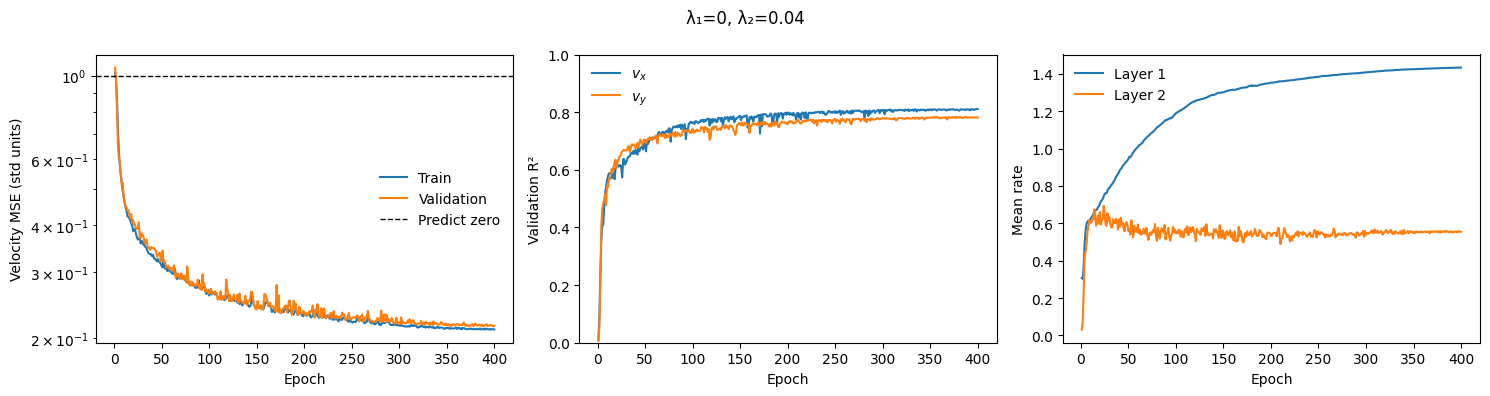

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
epochs = range(1, len(history["train"]) + 1)


tr = pd.DataFrame(history["train"])
va = pd.DataFrame(history["val"])
epochs = range(1, len(tr) + 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(epochs, tr["mse"], label="Train")
ax[0].plot(epochs, va["mse"], label="Validation")
ax[0].axhline(1.0, ls="--", lw=1, c="k", label="Predict zero")
ax[0].set(xlabel="Epoch", ylabel="Velocity MSE (std units)", yscale="log")

ax[1].plot(epochs, va["r2_x"], label="$v_x$")
ax[1].plot(epochs, va["r2_y"], label="$v_y$")
ax[1].set(xlabel="Epoch", ylabel="Validation R²", ylim=(0, 1))

ax[2].plot(epochs, va["rate1"], label="Layer 1")
ax[2].plot(epochs, va["rate2"], label="Layer 2")
ax[2].set(xlabel="Epoch", ylabel="Mean rate")

for a in ax:
    a.legend(frameon=False)
fig.suptitle(f"λ₁={L['lambda_1']:g}, λ₂={L['lambda_2']:g}")
fig.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.signal import convolve2d

def temporal_kernels(cnn):
    """(N1, D) kernels in plot orientation: lag 0 LAST, matching t_ms."""
    phi = cnn.temporal_w @ cnn.tbasis.T                 # (N1, D), lag 0 first
    phi = phi / (phi.norm(dim=1, keepdim=True) + 1e-8)  # same as forward()
    return phi.flip(-1).detach().cpu().numpy()          # lag 0 last

def acceptance_kernel(sigma_taps, truncate=3.0):
    """Ommatidial acceptance function sampled on the tap lattice."""
    r = max(1, int(round(truncate * sigma_taps)))
    ax = np.arange(-r, r + 1)
    g = np.exp(-ax ** 2 / (2 * sigma_taps ** 2))
    k = np.outer(g, g)
    return k / k.sum()


def effective_rf(cnn, dataset, truncate=3.0):
    """W1 convolved with the optics: the object comparable to a measured RF.

    The blur acted upstream of the network, so the learned weights carry no
    optics. Reverse-correlating the model against the *pre-blur* stimulus
    would recover this; convolving is exact because that path is linear.
    """
    sw = cnn.spatial_kernel[:, 0].detach().cpu().clone().numpy()
    sigma_taps = dataset.sigma_px / dataset.spacing_px
    k = acceptance_kernel(sigma_taps, truncate)
    eff = np.stack([convolve2d(w, k, mode="full") for w in sw])
    return eff, sigma_taps

def plot_cnn_subunits_1(cnn, dataset, effective=True, truncate=3.0):
    n_su, max_delay = cnn.num_subunits_1, cnn.max_delay
    tw = temporal_kernels(cnn)

    if effective:
        sw, sigma_taps = effective_rf(cnn, dataset, truncate)
        label = f"W₁ ⊛ O  (σ = {sigma_taps:.2f} taps)"
    else:
        sw = cnn.spatial_kernel[:, 0].detach().cpu().clone().numpy()
        label = "W₁ (weights only)"

    for n in range(n_su):                       # fix sign, push gain to time
        if abs(sw[n].min()) > sw[n].max():
            sw[n], tw[n] = -sw[n], -tw[n]
        s = np.linalg.norm(sw[n])
        sw[n] /= s
        tw[n] *= s

    k = sw.shape[-1]
    half = k * dataset.deg_per_tap / 2
    extent = [-half, half, -half, half]
    t_ms = np.arange(-max_delay + 1, 1) * (1000.0 / dataset.fps)
    vlim, ylim = np.abs(sw).max(), np.abs(tw).max()

    fig, axs = plt.subplots(n_su, 3, figsize=(8, 3.2 * n_su), squeeze=False,
                            gridspec_kw=dict(width_ratios=[1, 1.9, 0.1]))
    for n in range(n_su):
        axs[n, 0].plot(t_ms, tw[n])
        axs[n, 0].axhline(0, ls=":", c="k", lw=0.8)
        axs[n, 0].set_ylim(-ylim, ylim)
        axs[n, 0].tick_params(labelbottom=(n == n_su - 1))
        im = axs[n, 1].imshow(sw[n], cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                              extent=extent, interpolation="nearest")
        axs[n, 1].set_title(f"subunit 1,{n+1}")
        plt.colorbar(im, cax=axs[n, 2])
    axs[-1, 0].set_xlabel(r"$\Delta t$ [ms]")
    axs[-1, 1].set_xlabel("azimuth [deg]")
    fig.suptitle(label)
    fig.tight_layout()
    
    return fig, axs



def plot_cnn_subunits2(cnn: nn.Module):
    """
    Plot the second layer of subunits of a CNN.
    """
    cnn_filters_2 = cnn.layer2.weight.to("cpu").detach()

    fig, axs = plt.subplots(cnn.num_subunits_2,
                            cnn.num_subunits_1,
                            figsize=(4 * cnn.num_subunits_2,
                                    4 * cnn.num_subunits_1),
                            sharex=True, sharey=True)
    # vlim = abs(cnn_filters_2).max()
    percentile = 99
    vlim = torch.quantile(cnn_filters_2.abs().flatten(), percentile / 100).item()
    for i in range(cnn.num_subunits_2):
        for j in range(cnn.num_subunits_1):
            axs[i, j].imshow(cnn_filters_2[i, j],
                            vmin=-vlim, vmax=vlim, cmap="RdBu_r")

            axs[i, j].set_title('subunit 1,{} $\\to$ 2,{}'.format(j+1,i+1))


(<Figure size 800x3200 with 30 Axes>,
 array([[<Axes: >, <Axes: title={'center': 'subunit 1,1'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,2'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,3'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,4'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,5'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,6'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,7'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,8'}>, <Axes: >],
        [<Axes: >, <Axes: title={'center': 'subunit 1,9'}>, <Axes: >],
        [<Axes: xlabel='$\\Delta t$ [ms]'>,
         <Axes: title={'center': 'subunit 1,10'}, xlabel='azimuth [deg]'>,
         <Axes: >]], dtype=object))

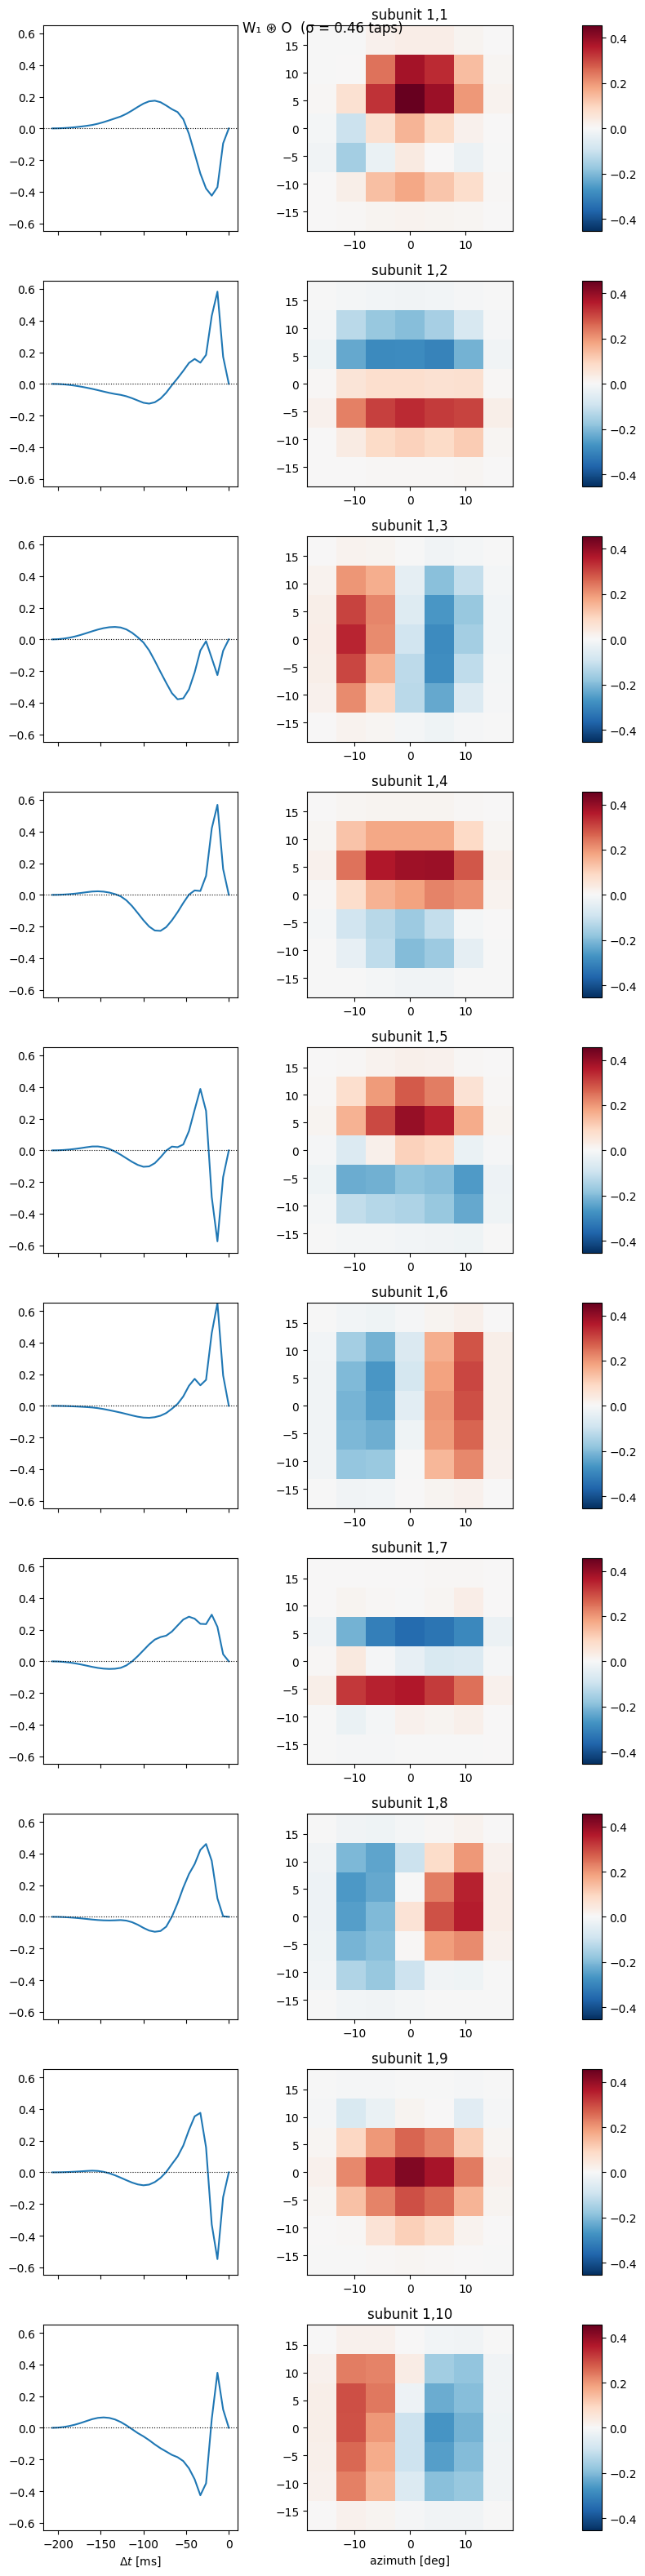

In [26]:
plot_cnn_subunits_1(model, info, effective=True)